#Samikshhya Gurung
#2417750

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.shape)
print(x_test.shape)
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [5]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [6]:
print(y_train[0])

5


In [7]:
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy", # labels are in integer
metrics=["accuracy"])

In [10]:
model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9604 - loss: 0.1301 - val_accuracy: 0.9834 - val_loss: 0.0509


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9834 - loss: 0.0509
Test accuracy: 0.9834


In [12]:
predictions = model.predict(x_test[:5])
print(predictions.shape)
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(5, 10)
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-tory represents a class. You are expected to write a code:


• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• What did you Observe?

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


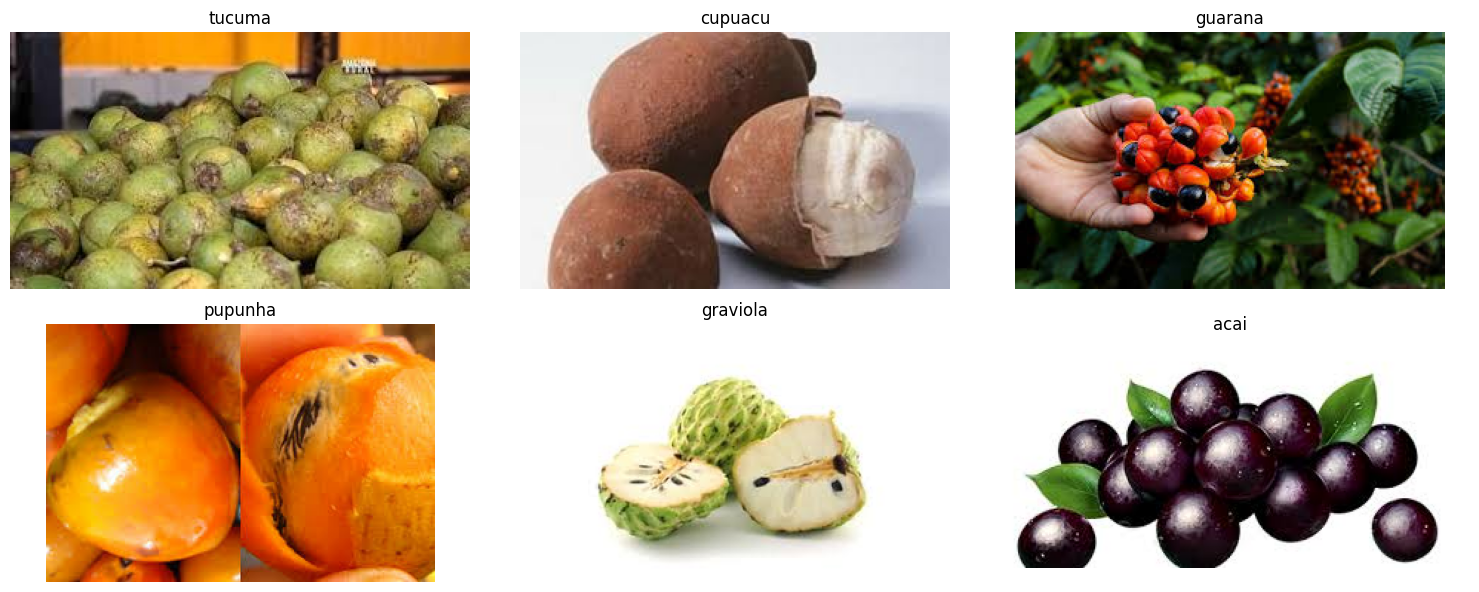

In [14]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to training dataset
train_dir = "/content/drive/MyDrive/AI and Machine Learning/week5/FruitinAmazon/train"

# Get list of class directories
classes = os.listdir(train_dir)

# Randomly select one image from each class
images = []
labels = []
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_file)
    images.append(mpimg.imread(img_path))
    labels.append(cls)

# Display images in a grid with 2 rows
fig, axes = plt.subplots(2, len(images)//2, figsize=(15, 6))
axes = axes.flatten()
for img, label, ax in zip(images, labels, axes):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()


2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”


In [15]:
import os
from PIL import Image

# Path to training dataset
train_dir = "/content/drive/MyDrive/AI and Machine Learning/week5/FruitinAmazon/train"

corrupted_images = []

# Iterate through each class subdirectory
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)
            try:
                # Try opening the image
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, SyntaxError):
                # If corrupted, remove and record
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")


No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:
In this section, we will load and preprocess image data from a directory using the

image dataset from directory function in Keras.

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.



###Define parameters:

In [16]:
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
rescale = tf.keras.layers.Rescaling(1./255)


###Load training dataset:

In [17]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.


###Load validation dataset:

In [18]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3- Implement a CNN with
Follow the following Structure and Hyper- parameters:

##Convolutional Architecture:

• Convolutional Layer 1:
– Filter Size (F): (3,3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling

– Filter Size (F): (2,2)
– Stride (s): 2

• Convolutional Layer 2:

– Filter Size (F): (3,3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

– Filter Size (F): (2,2)

– Stride (s): 2

Fully Connected Network Architecture:

• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer- 2:

– Number of Neurons: 64

– Number of Neurons: 128


• Output Layer:

– Number of Neurons: num classes (number of output classes

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define number of classes based on dataset
num_classes = 10  # replace with actual number of classes

# Build the CNN model
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                  input_shape=(128, 128, 3)),  # adjust input shape to your dataset
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten + Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,970 (8.08 MB)

 Trainable params: 2,116,970 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model

##Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#Task 4: Train the Model

##Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid
ing overfitting

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_ds,
    batch_size=16,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.1655 - loss: 2.2827

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 952ms/step - accuracy: 0.1528 - loss: 2.2843 - val_accuracy: 0.0000e+00 - val_loss: 1.9886
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.2639 - loss: 1.7961

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.2917 - loss: 1.7786 - val_accuracy: 0.8333 - val_loss: 1.2270
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.3194 - loss: 1.6872 - val_accuracy: 0.3333 - val_loss: 1.6479
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.3333 - loss: 1.5422 - val_accuracy: 0.6667 - val_loss: 1.2531
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6863 - loss: 1.1896

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 477ms/step - accuracy: 0.6528 - loss: 1.2215 - val_accuracy: 0.7222 - val_loss: 0.9381
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.5833 - loss: 1.0776 - val_accuracy: 0.7222 - val_loss: 1.0450
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.6042 - loss: 0.9186

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 828ms/step - accuracy: 0.6250 - loss: 0.9385 - val_accuracy: 0.7222 - val_loss: 0.9159
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 707ms/step - accuracy: 0.8194 - loss: 0.7411 - val_accuracy: 0.5556 - val_loss: 1.2796
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8762 - loss: 0.5814

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - accuracy: 0.8472 - loss: 0.6063 - val_accuracy: 0.8333 - val_loss: 0.5827
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 509ms/step - accuracy: 0.9028 - loss: 0.4362 - val_accuracy: 0.6667 - val_loss: 0.9458
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.9028 - loss: 0.3743 - val_accuracy: 0.8333 - val_loss: 1.0422
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 507ms/step - accuracy: 0.9444 - loss: 0.2920 - val_accuracy: 0.7778 - val_loss: 0.8040
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9398 - loss: 0.2598

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.9444 - loss: 0.2477 - val_accuracy: 0.7778 - val_loss: 0.5071
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 679ms/step - accuracy: 0.9444 - loss: 0.1491 - val_accuracy: 0.7778 - val_loss: 0.6427
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 733ms/step - accuracy: 1.0000 - loss: 0.1090 - val_accuracy: 0.7778 - val_loss: 0.6620
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9497 - loss: 0.1644

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.9583 - loss: 0.1446 - val_accuracy: 0.8333 - val_loss: 0.4653
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.9861 - loss: 0.0875 - val_accuracy: 0.7778 - val_loss: 0.8669
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9398 - loss: 0.1679

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 566ms/step - accuracy: 0.9444 - loss: 0.1522 - val_accuracy: 0.8333 - val_loss: 0.3999
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9797 - loss: 0.0782

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.9861 - loss: 0.0726 - val_accuracy: 0.8889 - val_loss: 0.3594
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 730ms/step - accuracy: 1.0000 - loss: 0.0439 - val_accuracy: 0.8333 - val_loss: 0.4506
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 724ms/step - accuracy: 1.0000 - loss: 0.0258 - val_accuracy: 0.8333 - val_loss: 0.4584
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 1.0000 - loss: 0.0220 - val_accuracy: 0.8333 - val_loss: 0.5241
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 1.0000 - loss: 0.0237 - val_accuracy: 0.8333 - val_loss: 0.5776
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.7778 - val_loss: 0.6738
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 0.8333 - val_loss: 0.6276
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.8333 - val_lo

#Task 5: Evaluate the Model

#Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [22]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8889 - loss: 0.3594
Validation Accuracy: 0.8888888955116272


#Task 6: Save and Load the Model

## Model Saving and Loading
• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [23]:
model.save("fruit_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8889 - loss: 0.3594


[0.3594213128089905, 0.8888888955116272]

# Task 7: Predictions and Classification Report

##Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [25]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Get unique labels from both true and predicted values
unique_labels = np.unique(np.concatenate((y_true, y_pred)))

# Create target names corresponding to the unique labels
# The `classes` variable already stores the class names in order of their integer labels.
# So, we can just pick the names using the unique_labels as indices.
display_target_names = [classes[i] for i in unique_labels if i < len(classes)]

# Ensure that the labels and target_names are aligned
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=display_target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
              precision    recall  f1-score   support

     cupuacu       0.00      0.00      0.00         0
    graviola       1.00      1.00      1.00         3
        acai       1.00      0.87      0.93        15

    accuracy                           0.89        18
   macro avg       0.67      0.62      0.64        18
weighted avg       1.00      0.89      0.94        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Expected Deliverables

• Code Implementation: Complete code for building, training, evaluating, saving, and loading
the model.

• Visualization: Graphs showing the training and validation loss and accuracy.

• Classification Report: Display the final Classification Report on test data.

• Saved Model: Submit the saved .h5 model file.

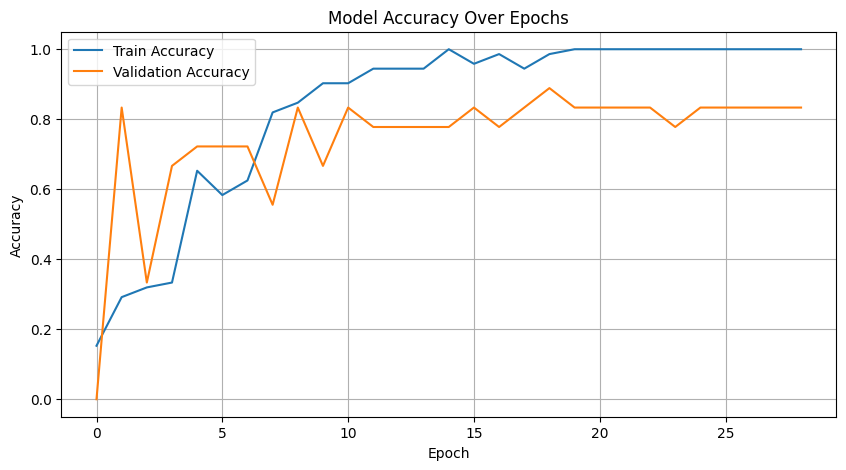

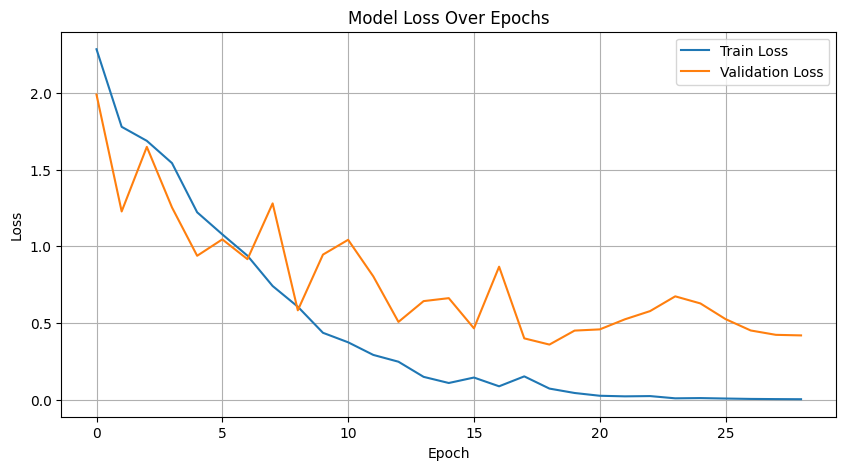

In [28]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()